## Домашнее задание
Как узнать свою аудиторию? Построение различных вариантов кластеризаций и интерпретация результатов.

### Цель:
На этот раз займемся классической задачкой - сегментация клиентов (в данном случае - банка). Крайне полезная операция, которая позволяет вам лучше познакомиться со своей аудиторией, понять, на какие группы она делится и чем они характеризуются.

#### Описание/Пошаговая инструкция выполнения домашнего задания:
##### Часть 1. EDA и Preprocessing

1. Скачайте данные по клиентам немецкого банка: https://www.kaggle.com/uciml/german-credit;
2. Проведите EDA, чтобы познакомиться с признаками;
3. Преобразуйте все признаки в числовые подходящими методами;
4. Приведите все данные к одному масштабу (а заодно поясните, почему это необходимая операция при кластеризации).

##### Часть 2. Моделирование

1. Постройте три варианта кластеризации: k-means, hierarhical и DBSCAN, подберите оптимальное количество кластеров для каждого метода при помощи Elbow method и Silhouette plot;
2. Также воспользуйтесь различными вариантами сжатия признакового пространства (PCA, UMAP, tSNE) и визуализируйте результаты кластеризации на двумерной плоскости.

##### Часть 3. Интерпретация

1. Теперь ваша задача - попытаться проинтерпретировать получившиеся кластеры, начните с простого расчета средних значений признаков для каждого из кластеров, есть ли интересные закономерности?
2. Теперь постройте boxplot-ы для каждого признака, сгруппировав значения по кластерам, по каким признакам заметно наибольшее отличие кластеров друг от друга? Можно ли их интерпретировать?

### Критерии оценки:
- EDA и Preprocessing - 2 балла.
- Моделирование - 5 баллов.
- Интерпретация - 3 балла.

## Решение

### Описание датасета

#### Context
The original dataset contains 1000 entries with 20 categorial/symbolic attributes prepared by Prof. Hofmann. In this dataset, each entry represents a person who takes a credit by a bank. Each person is classified as good or bad credit risks according to the set of attributes. 

#### Content
It is almost impossible to understand the original dataset due to its complicated system of categories and symbols. Thus, I wrote a small Python script to convert it into a readable CSV file. Several columns are simply ignored, because in my opinion either they are not important or their descriptions are obscure. The selected attributes are:

- Age (numeric)
- Sex (text: male, female)
- Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)
- Housing (text: own, rent, or free)
- Saving accounts (text - little, moderate, quite rich, rich)
- Checking account (numeric, in DM - Deutsch Mark)
- Credit amount (numeric, in DM)
- Duration (numeric, in month)
- Purpose (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)

### 1. EDA и Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

1. На EDA посмотреть на данные в сниженной размерности, чтобы оценить характер их распределения
2. Числовые данные необходимо масштабировать так как в моделях считается расстояние между наблюдениями
3. При кластеризации следует стремиться, чтобы наименьший кластер содержал более 5% данных

In [4]:
df = pd.read_csv('./german_credit_data.csv', sep=',')

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [6]:
# Пропуски в столбцах Saving accounts и Checking account
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [7]:
# В предположение, что признаки Saving accounts и Checking account обозначают совокупный размер сберегательных счетов и размер текущего счета,
# для пустых значений в этих столбцах ввожу новую категорию 'empty'
df[['Saving accounts','Checking account']] = df[['Saving accounts','Checking account']].fillna('empty')

In [8]:
# Удаляю первый столбец так как он похож на порядковый номер строки и потому ценности не представляет
drop_features = ['Unnamed: 0']

binary_features = [
    'Sex',
]

ordered_features = [
    'Housing',
    'Saving accounts',
    'Checking account'
]

category_features = [
    'Purpose',
]

In [9]:
clean_df = df.drop(labels=drop_features, axis=1)

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [10]:
for feature in ordered_features + category_features + binary_features:
    print(f'{feature}: \n\t{clean_df[feature].unique()}')

Housing: 
	['own' 'free' 'rent']
Saving accounts: 
	['empty' 'little' 'quite rich' 'rich' 'moderate']
Checking account: 
	['little' 'moderate' 'empty' 'rich']
Purpose: 
	['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']
Sex: 
	['male' 'female']


In [11]:
# Преобразование нечисловых признаков
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

def get_encoded_feature_name(feature, category):
    return str(feature) + "_" + str(category)


ordinal_encoder = OrdinalEncoder(categories=[
        ['rent', 'free', 'own'],
        ['empty', 'little', 'moderate',  'quite rich', 'rich'],
        ['empty', 'little', 'moderate',  'quite rich', 'rich'],
    ],
    dtype=np.int16
)

binary_encoder = OneHotEncoder(
    sparse_output=False, 
    drop='if_binary', 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)

category_encoder = OneHotEncoder(
    sparse_output=False, 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)

encoded_df = clean_df.copy()
encoded_df[binary_encoder.get_feature_names_out()] = binary_encoder.fit_transform(encoded_df[binary_features])
encoded_df[ordered_features] = ordinal_encoder.fit_transform(encoded_df[ordered_features])
encoded_df[category_encoder.get_feature_names_out()] = category_encoder.fit_transform(encoded_df[category_features])

encoded_df = encoded_df.drop(binary_features + category_features, axis=1)
encoded_df.head()

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,2,0,1,1169,6,1,0,0,0,0,0,1,0,0
1,22,2,2,1,2,5951,48,0,0,0,0,0,0,1,0,0
2,49,1,2,1,0,2096,12,1,0,0,0,1,0,0,0,0
3,45,2,1,1,1,7882,42,1,0,0,0,0,1,0,0,0
4,53,2,1,1,1,4870,24,1,0,1,0,0,0,0,0,0


In [12]:
encoded_df.describe()

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,35.546000,1.904000,1.534000,1.190000,1.06400,3271.258000,20.903000,0.690000,0.097000,0.337000,0.01200,0.059000,0.181000,0.280000,0.022000,0.01200
std,11.375469,0.653614,0.779392,0.966869,1.10776,2822.736876,12.058814,0.462725,0.296106,0.472921,0.10894,0.235743,0.385211,0.449224,0.146757,0.10894
min,19.000000,0.000000,0.000000,0.000000,0.00000,250.000000,4.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,27.000000,2.000000,1.000000,1.000000,0.00000,1365.500000,12.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,33.000000,2.000000,2.000000,1.000000,1.00000,2319.500000,18.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,42.000000,2.000000,2.000000,1.000000,2.00000,3972.250000,24.000000,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.00000
max,75.000000,3.000000,2.000000,4.000000,4.00000,18424.000000,72.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000


In [13]:
synthetic_category_feature = [column for column in encoded_df.columns for category_feature in category_features if category_feature in column]
synthetic_category_feature

['Purpose_business',
 'Purpose_car',
 'Purpose_domestic appliances',
 'Purpose_education',
 'Purpose_furniture/equipment',
 'Purpose_radio/TV',
 'Purpose_repairs',
 'Purpose_vacation/others']

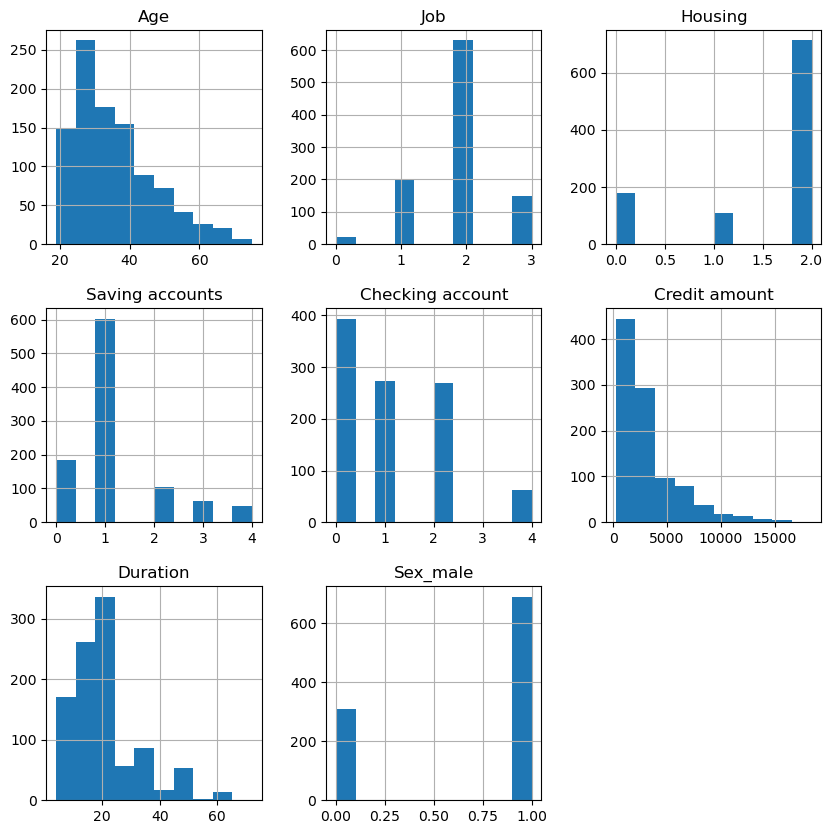

In [ ]:
# Гистограммы распределения всех числовых значений за исключением категориальных признаков
synthetic_category_feature = [column for column in encoded_df.columns for category_feature in category_features if category_feature in column]

encoded_df.drop(synthetic_category_feature, axis=1).hist(figsize=(10,10))

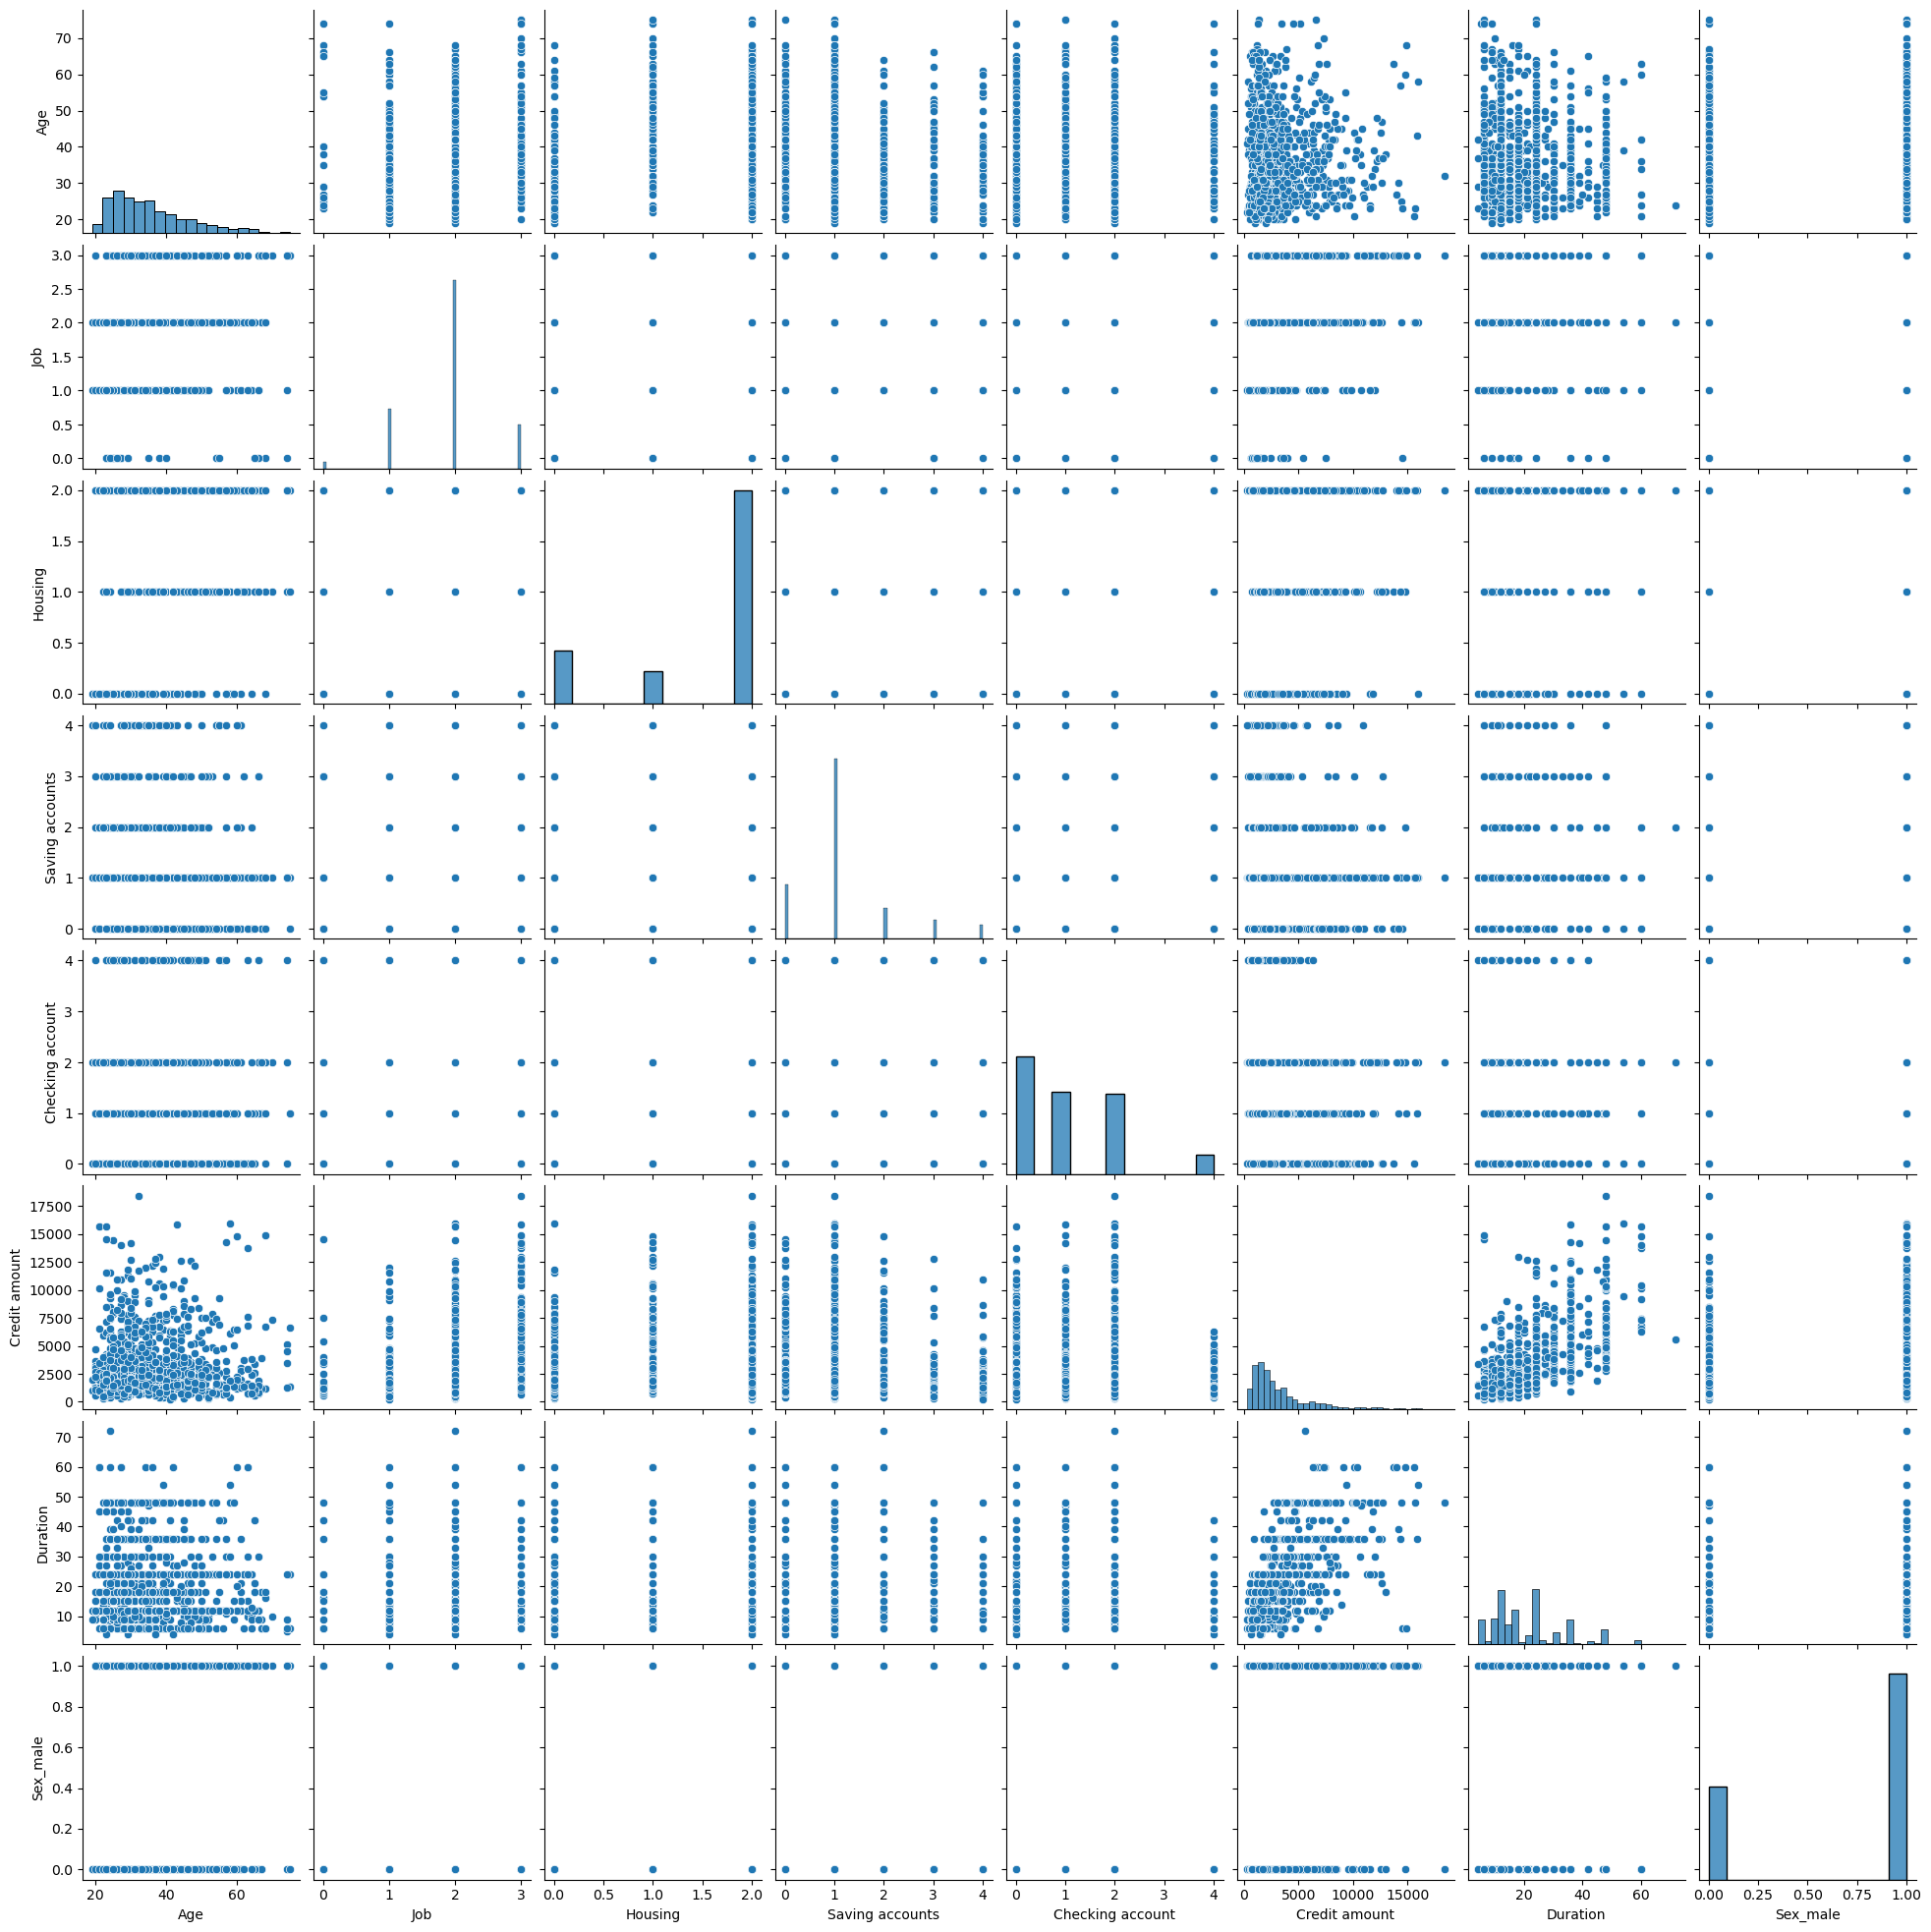

In [ ]:
sns.pairplot(encoded_df.drop(synthetic_category_feature, axis=1))

<Axes: >

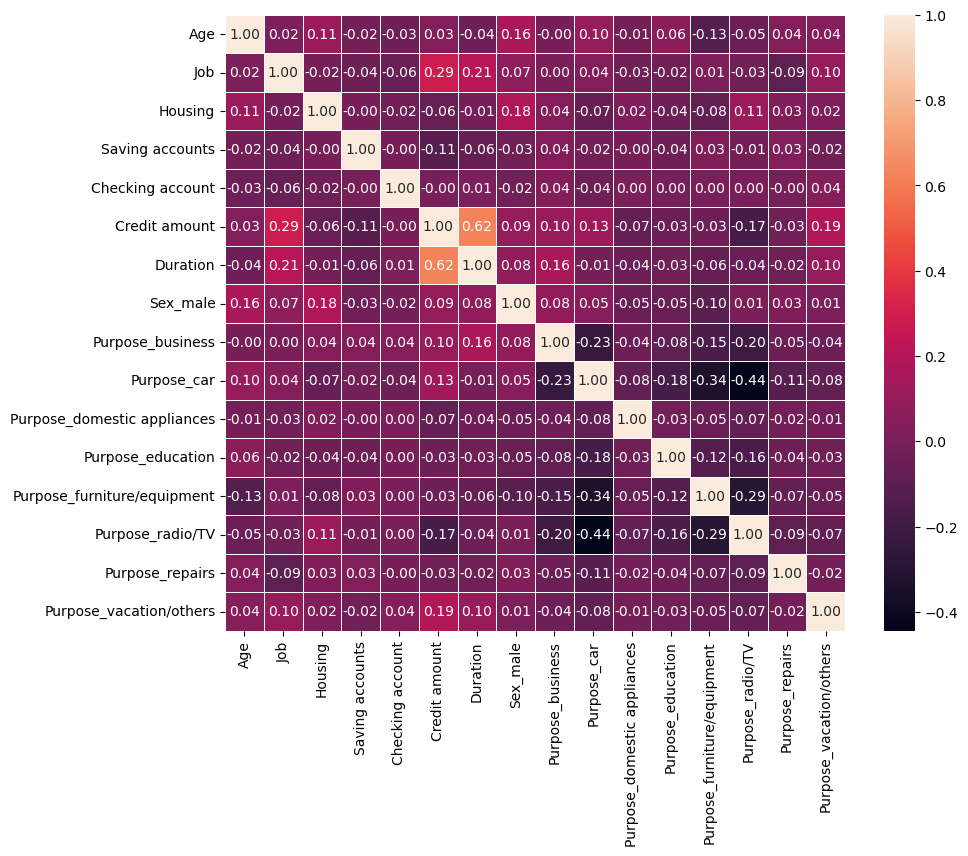

In [16]:
# Корреляция
plt.figure(figsize=(10, 8))
sns.heatmap(encoded_df.corr(), annot=True, cbar=True, linewidths=.5, fmt= '.2f')

#### Нормализация

Числовые данные необходимо нормализовать, так как в моделях считается расстояние между наблюдениями и для этого важен единый масштаб.

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(encoded_df)
scaled_df = pd.DataFrame(scaler.transform(encoded_df), columns=encoded_df.columns)

scaled_df.describe()

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.295464,0.634667,0.767000,0.297500,0.26600,0.166241,0.248574,0.690000,0.097000,0.337000,0.01200,0.059000,0.181000,0.280000,0.022000,0.01200
std,0.203133,0.217871,0.389696,0.241717,0.27694,0.155317,0.177336,0.462725,0.296106,0.472921,0.10894,0.235743,0.385211,0.449224,0.146757,0.10894
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.142857,0.666667,0.500000,0.250000,0.00000,0.061379,0.117647,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,0.250000,0.666667,1.000000,0.250000,0.25000,0.113871,0.205882,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,0.410714,0.666667,1.000000,0.250000,0.50000,0.204812,0.294118,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.00000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000


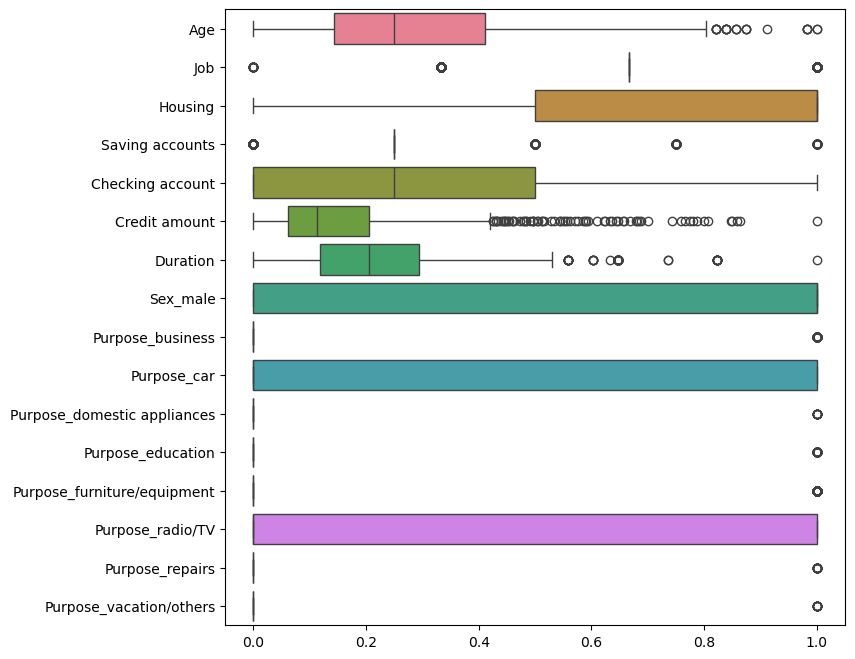

In [ ]:
plt.figure(figsize=(8,8))
sns.boxplot(data=scaled_df, orient='h')

#### Визуализация данных в сниженной размерности

In [221]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from umap import UMAP

tsne = TSNE(n_components=2, random_state=10)
X_tsne = tsne.fit_transform(scaled_df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)

umap = UMAP(n_components=2)
X_umap = umap.fit_transform(scaled_df)

dim_reductions = [('TSNE', X_tsne), ('PCA', X_pca), ('UMAP', X_umap)]


In [ ]:
# Вспомогательные функции
def get_label_percents(labels):
    total_label_count = len(labels)
    unique_labels, counts = np.unique(labels, axis=0, return_counts=True)
    return (len(unique_labels), [f"{i}: {100 * (label_count/total_label_count):.2f}%" for i, label_count in enumerate(counts)])

def print_in_dim_reductions(title=None, labels=None):
    if labels is not None:
        k_num, labels_percents = get_label_percents(labels)
        print(f'K{k_num}: {labels_percents}')
        
    fig, axs = plt.subplots(ncols=len(dim_reductions), figsize=(16, 4))

    for i, (method, X) in enumerate(dim_reductions):
        g = sns.scatterplot(x=X[:,0], y=X[:,1], palette='tab20', hue=labels, ax=axs[i])
        g.set_title(f'{method} {title if title is not None else ""}')
        g.set(xticklabels=[])
        g.set(yticklabels=[])
        if labels is not None:
            g.legend(loc='upper left', bbox_to_anchor=(1, 1))

    fig.tight_layout()

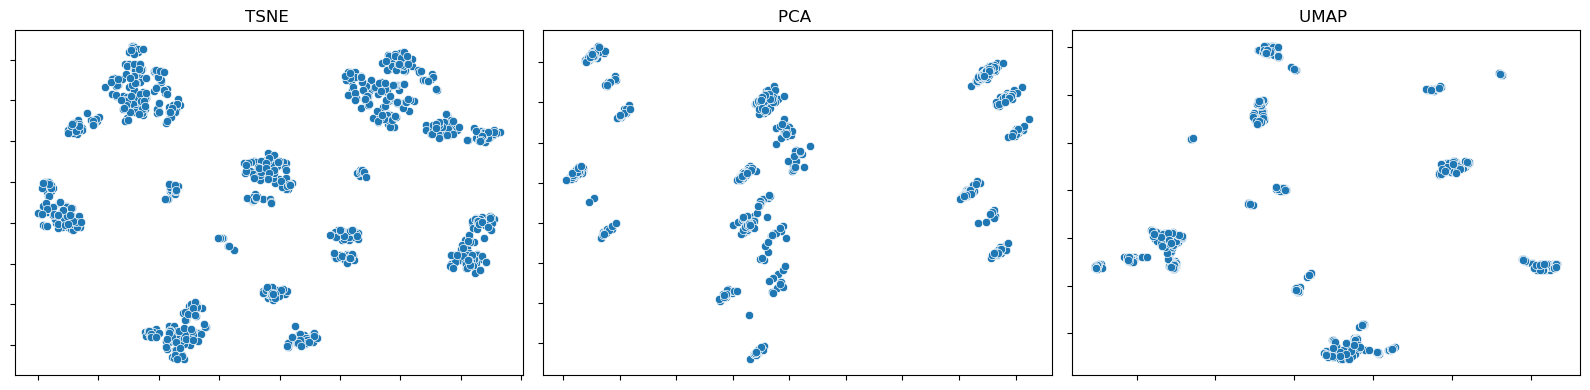

In [275]:
print_in_dim_reductions()

### 2. Моделирование

In [195]:
from sklearn.metrics import silhouette_score

#### **K-means**

##### Определение числа кластеров по методу локтя

In [77]:
from sklearn.cluster import KMeans

MIN_CLUSTER_COUNT = 1
MAX_CLUSTER_COUNT = 10

# Расчет инерции
inertia = []
inertia_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT + 1)
for i in inertia_iterations:
    kmeans = KMeans(n_clusters=i, random_state=10).fit(scaled_df)
    inertia_i = kmeans.inertia_
    inertia.append(inertia_i)

# Расчет переломного момента
D = []
D_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT - 1)
for i in D_iterations:
    Di = (inertia[i] - inertia[i+1])/(inertia[i-1] - inertia[i])
    D.append(Di)

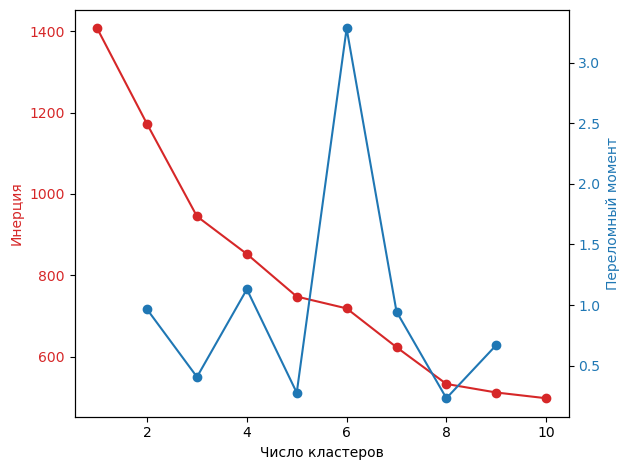

In [78]:
fig, ax1 = plt.subplots()

# Общая шкала аргумента
ax1.set_xlabel('Число кластеров')

# Совмещение графиков
ax2 = ax1.twinx()

# График инерции
color = 'tab:red'
ax1.set_ylabel('Инерция', color=color)
ax1.plot(inertia_iterations, inertia, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# График переломного момента
color = 'tab:blue'
ax2.set_ylabel('Переломный момент', color=color)
# Для переломного момента индекс для числа кластеров смещается на 1
D_num_clusters = np.array(D_iterations) + 1
ax2.plot(D_num_clusters, D, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

**Выводы по методу локтя**: подходящее число кластеров 3, 5, 8

K3: ['0: 27.50%', '1: 28.00%', '2: 44.50%']
K5: ['0: 5.90%', '1: 28.00%', '2: 33.70%', '3: 10.70%', '4: 21.70%']
K8: ['0: 5.90%', '1: 19.50%', '2: 4.60%', '3: 24.30%', '4: 18.10%', '5: 9.70%', '6: 8.50%', '7: 9.40%']


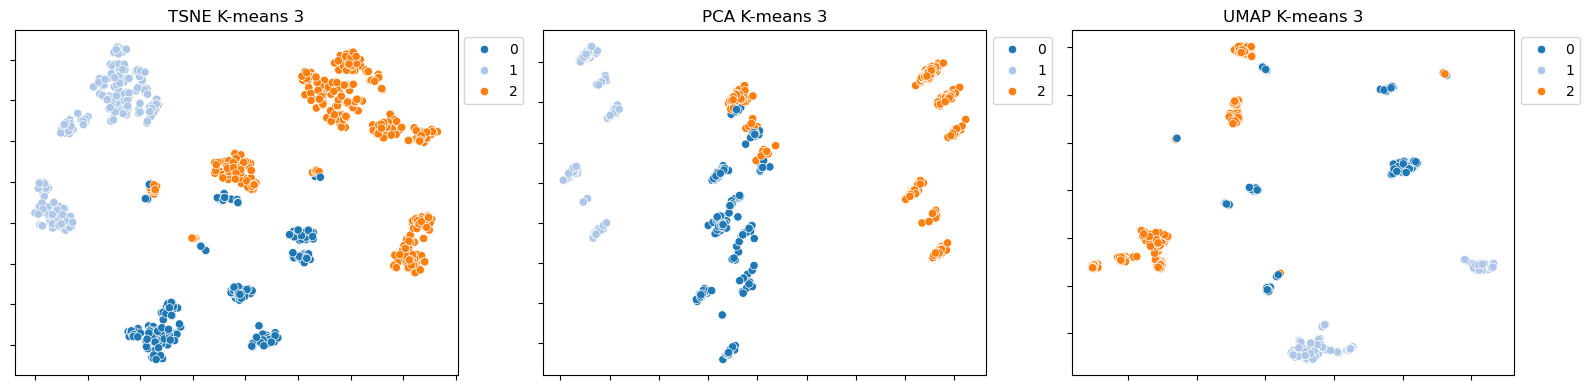

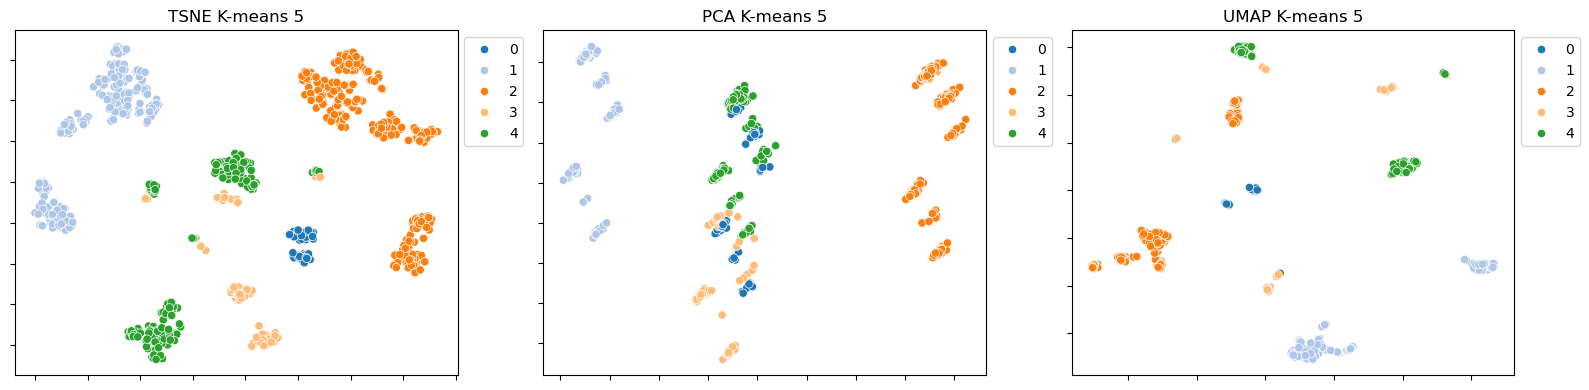

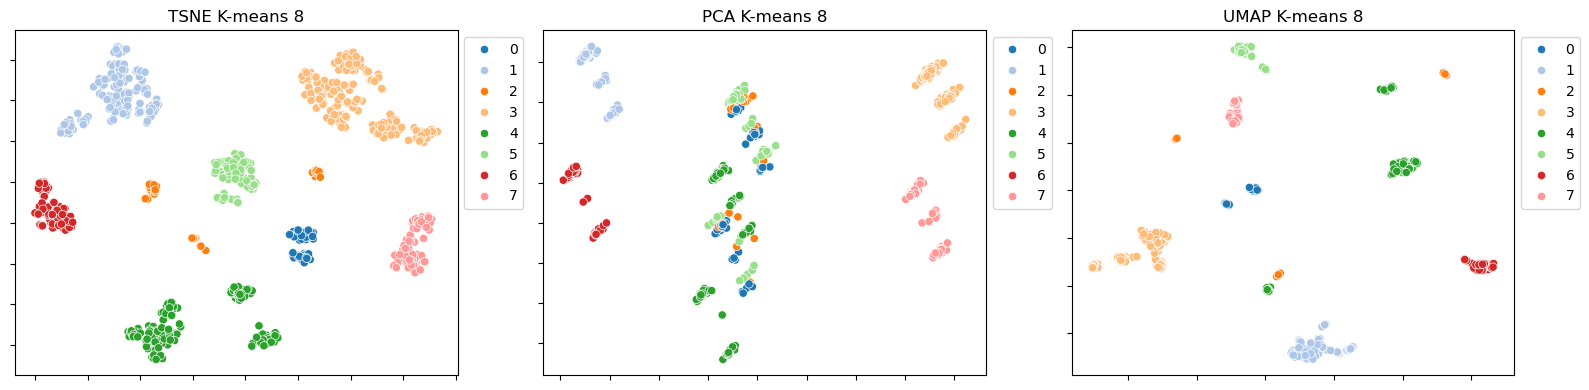

In [276]:
for i, num_cluster in enumerate([3, 5, 8]):
    labels = KMeans(n_clusters=num_cluster, random_state=10).fit(scaled_df).labels_
    print_in_dim_reductions(labels=labels, title=f'K-means {num_cluster}')

**Выводы по K-means**: по пространствам сниженной размерности выглядит гармоничным разделение на 8 кластеров, особенно при методах TSNE и UMAP

#### **Hierarhical**

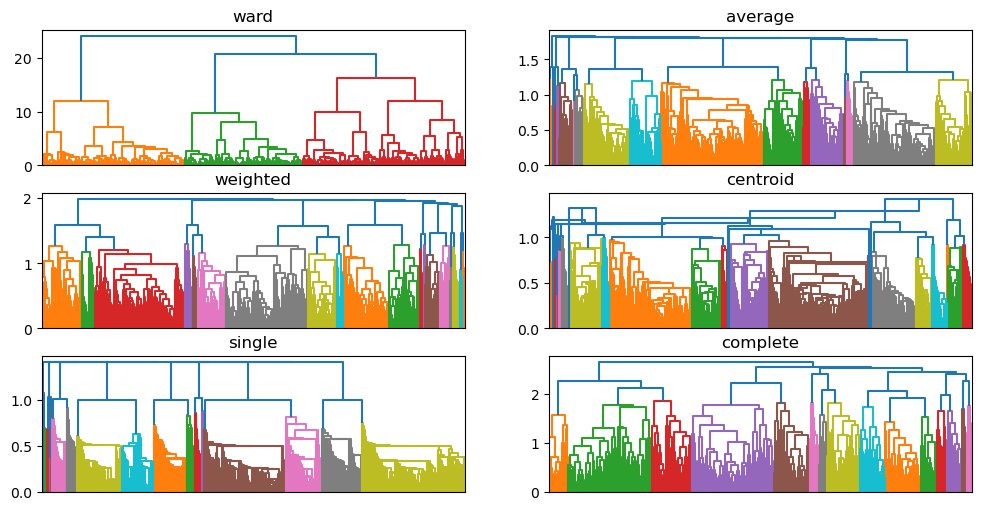

In [ ]:
# Проверка числа кластеров по дендрограммам
from scipy.cluster.hierarchy import dendrogram, linkage

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 6))

for i, method in enumerate(['ward', 'average', 'weighted', 'centroid', 'single', 'complete']):
    ax = axs[i//2][i%2]
    ax.set_title(method)
    linkage_ = linkage(scaled_df, method=method)
    dendrogram_ = dendrogram(linkage_, no_labels=True, ax=ax)
    

**Выводы по дендрограммам**: наиболее наглядное представления дают методы *ward* и *single* по нимм можно выделить от 3 до 8 кластеров

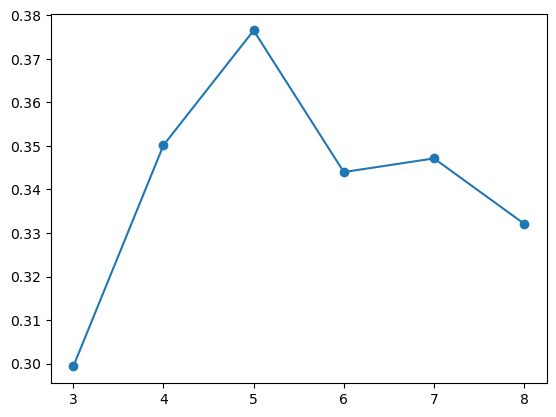

In [ ]:
# Проверка числа кластеров по силуэтному коээфициенту
from sklearn.cluster import AgglomerativeClustering

NUM_CLUSTERS = range(3, 9)

silhouette = []
for i in NUM_CLUSTERS:
    agg = AgglomerativeClustering(n_clusters=i).fit(scaled_df)
    labels = agg.labels_
    score = silhouette_score(scaled_df, labels)
    silhouette.append(score)

plt.plot(NUM_CLUSTERS, silhouette, marker='o')

**Вывод по силуэтному коэффициенту**: наибольшее значение коэффициента при числе кластеров 5 

K4: ['0: 20.20%', '1: 33.70%', '2: 28.00%', '3: 18.10%']
K5: ['0: 33.70%', '1: 18.10%', '2: 28.00%', '3: 10.50%', '4: 9.70%']
K7: ['0: 28.00%', '1: 10.50%', '2: 7.40%', '3: 24.30%', '4: 9.70%', '5: 9.40%', '6: 10.70%']


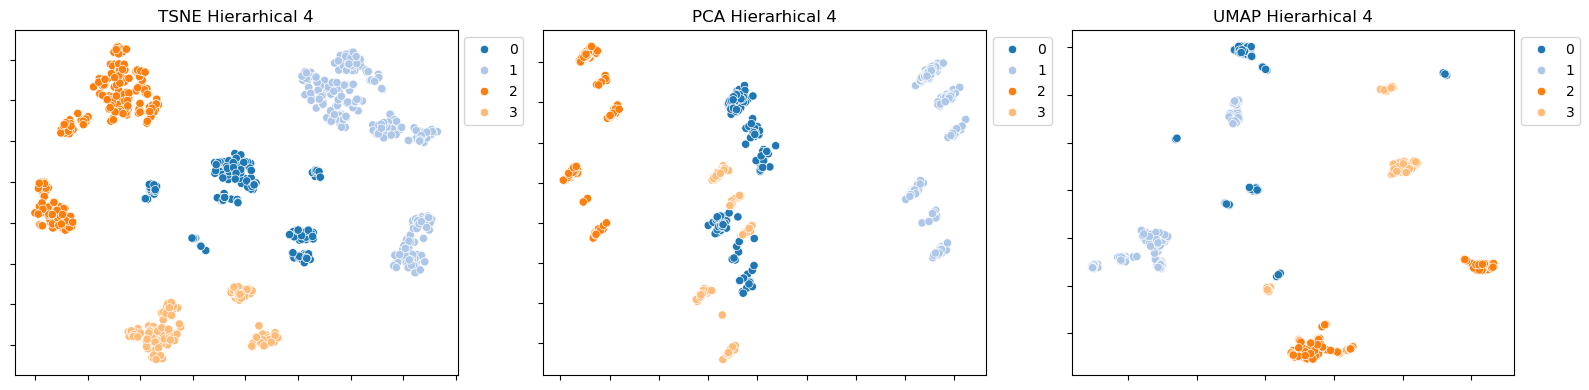

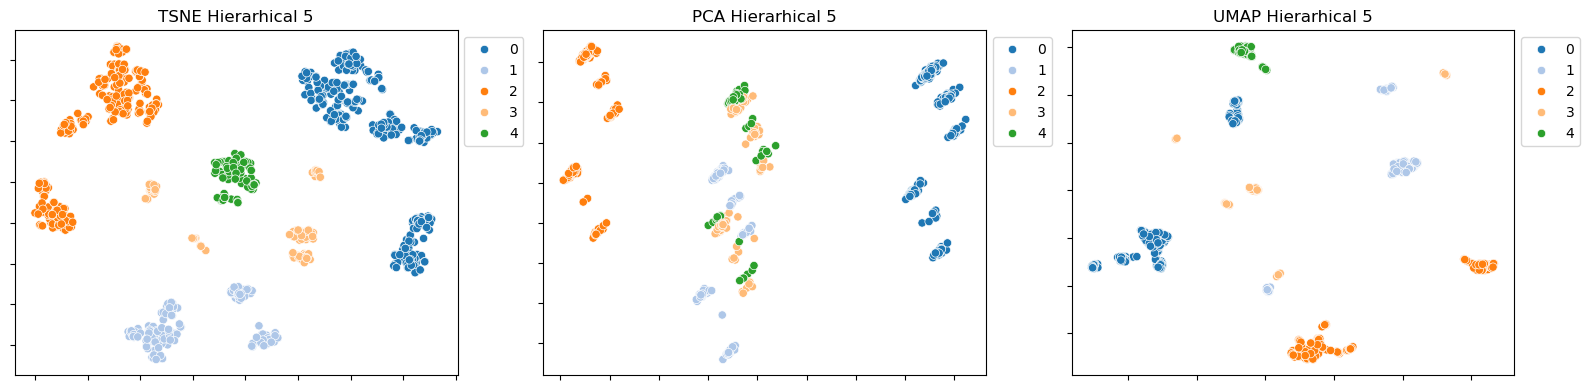

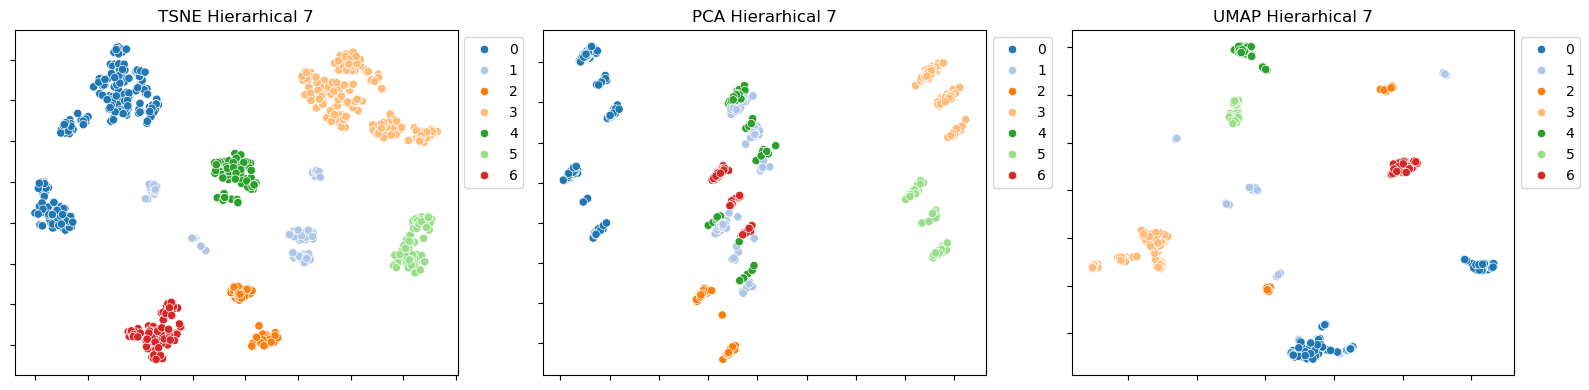

In [277]:
NUM_CLUSTERS = [4, 5, 7]

for i in NUM_CLUSTERS:
    labels = AgglomerativeClustering(n_clusters=i).fit(scaled_df).labels_
    print_in_dim_reductions(labels=labels, title=f'Hierarhical {i}')

**Выводы по Hierarhical**: данный метод приводит к меньшему числу пермешивания элементов между группами в сниженной размерности относительно K-means. Своё предпочтение по числу кластеров я отдаю 5 и 7 в зависимости от потребности укрупнения.

#### **DBSCAN**

In [264]:
from sklearn.cluster import DBSCAN

def dbscan_clustering(eps_range, X):
    eps_range = eps_range
    silhouette = []
    clusters = []
    for i in eps_range:
        dbscan = DBSCAN(eps=i).fit(X)
        labels = dbscan.labels_
        uniq_labels = np.unique(labels)
        n_clusters = len(uniq_labels[uniq_labels != -1])
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = 0
        silhouette.append(score)
        clusters.append(n_clusters)
        
    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.plot(eps_range, silhouette, marker='o', color=color)
    ax1.set_xlabel('eps')
    ax1.set_ylabel('silhouette', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:blue'
    ax2.plot(eps_range, clusters, marker='o', color=color)
    ax2.set_ylabel('n_clusters', color=color)  
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

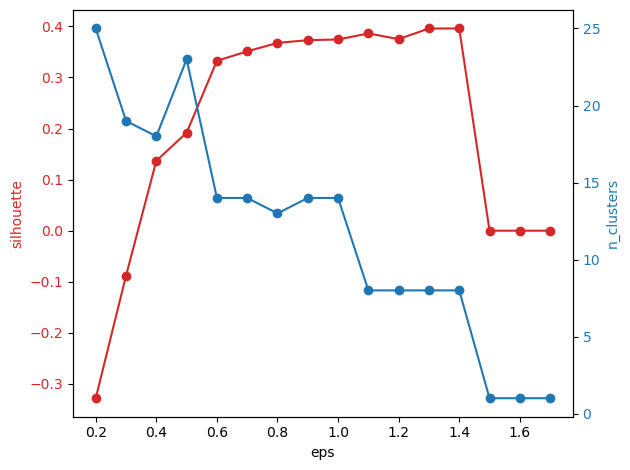

In [265]:
eps_range = np.arange(0.2,1.8,0.1)
dbscan_clustering(eps_range, scaled_df)

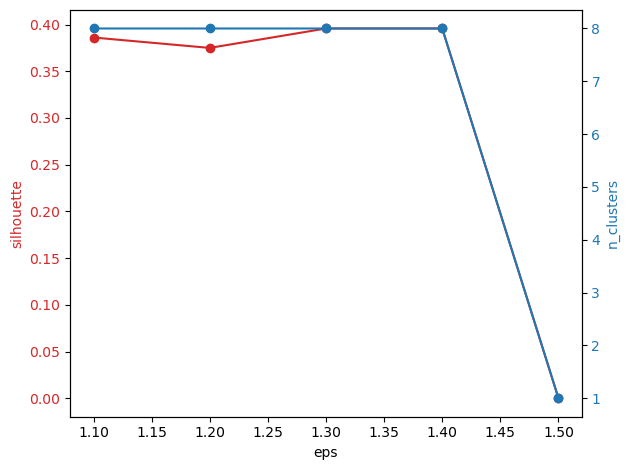

In [ ]:
# Укрупнение интервала с наивысшей метрикой силуэтгного коэффициента
eps_range = np.arange(1.1,1.6,0.1)
dbscan_clustering(eps_range, scaled_df)

**Вывод по силуэтному коэффициенту**: наибольшее значение коэффициента при числе кластеров 8, радиус окружности выбираю 1.35

K10: ['0: 28.00%', '1: 5.90%', '2: 10.70%', '3: 24.30%', '4: 9.40%', '5: 9.70%', '6: 7.40%', '7: 1.20%', '8: 2.20%', '9: 1.20%']


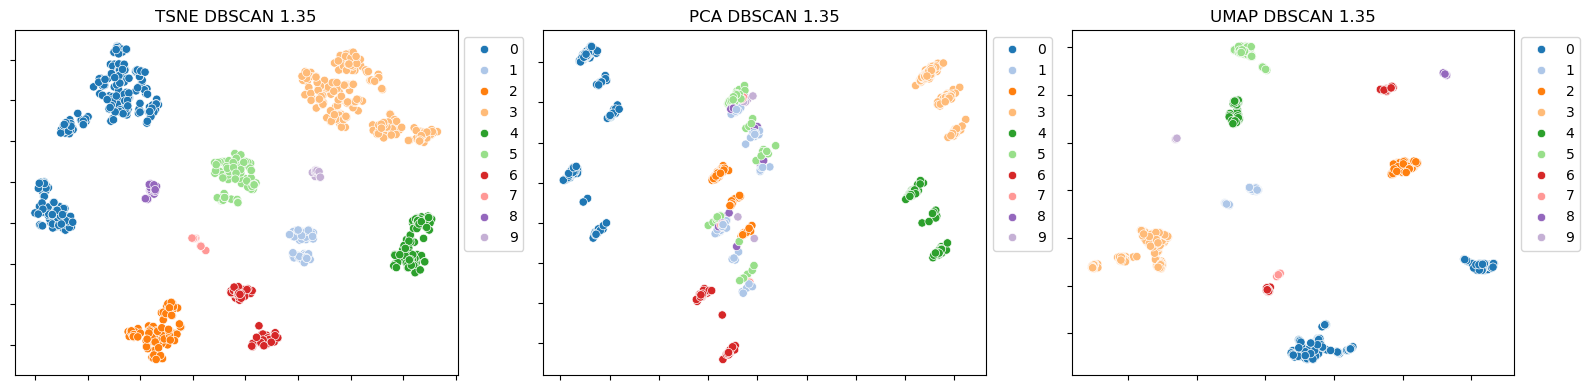

In [294]:
EPS_RANGE = [1.35]

for i in EPS_RANGE:
    labels = DBSCAN(eps=i).fit(scaled_df).labels_
    print_in_dim_reductions(labels=labels, title=f'DBSCAN {i}')

**Выводы по DBSCAN**: визуально разделение произошло хуже, чем для Hierarhical (к=7) - на графике PCA больше видно смешивания точек, а на UMAP больше объединений в один кластер для удаленных "облаков".

### 3. Интерпретация

Считаю, что лучшим разделением на кластеры было Hierarhical (к=7), его выбираю для дальнейшей интерпретации.

K7: ['0: 16.60%', '1: 28.00%', '2: 7.40%', '3: 24.30%', '4: 4.60%', '5: 9.70%', '6: 9.40%']


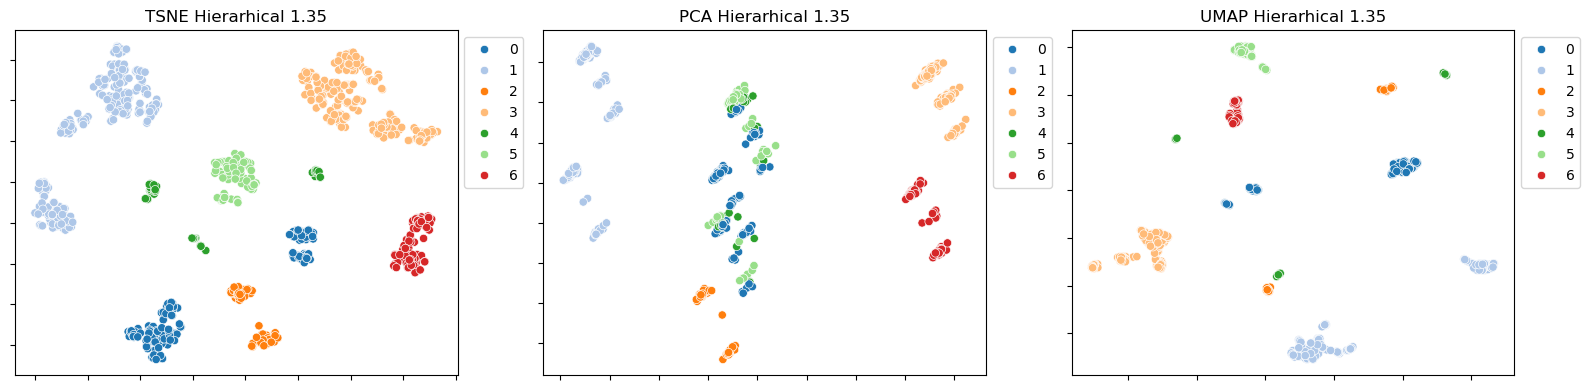

In [305]:
labels = AgglomerativeClustering(n_clusters=7).fit(scaled_df).labels_
print_in_dim_reductions(labels=labels, title=f'Hierarhical {i}')

In [ ]:
encoded_df['labels'] = labels
encoded_df.groupby('labels').agg(['median', 'mean']).T.round(2)

labels                                    0        1        2        3  \
Age                         median    34.00    32.00    26.00    36.00   
                            mean      36.01    34.70    29.14    38.47   
Job                         median     2.00     2.00     2.00     2.00   
                            mean       1.90     1.88     1.92     1.97   
Housing                     median     2.00     2.00     2.00     2.00   
                            mean       1.57     1.68     1.04     1.56   
Saving accounts             median     1.00     1.00     1.00     1.00   
                            mean       1.16     1.17     1.28     1.11   
Checking account            median     1.00     1.00     1.00     1.00   
                            mean       1.02     1.07     1.19     1.01   
Credit amount               median  2467.50  1890.00  2166.00  2799.00   
                            mean    3130.53  2487.65  2774.73  3922.33   
Duration                    median    18.00    18.00    15.00    18.00   
                            mean      20.05    20.05    17.89    21.09   
Sex_male                    median     1.00     1.00     0.00     1.00   
                            mean       0.86     0.70     0.00     1.00   
Purpose_business            median     0.00     0.00     0.00     0.00   
                            mean       0.00     0.00     0.00     0.00   
Purpose_car                 median     0.00     0.00     0.00     1.00   
                            mean       0.00     0.00     0.00     1.00   
Purpose_domestic appliances median     0.00     0.00     0.00     0.00   
                            mean       0.00     0.00     0.00     0.00   
Purpose_education           median     0.00     0.00     0.00     0.00   
                            mean       0.36     0.00     0.00     0.00   
Purpose_furniture/equipment median     1.00     0.00     1.00     0.00   
                            mean       0.64     0.00     1.00     0.00   
Purpose_radio/TV            median     0.00     1.00     0.00     0.00   
                            mean       0.00     1.00     0.00     0.00   
Purpose_repairs             median     0.00     0.00     0.00     0.00   
                            mean       0.00     0.00     0.00     0.00   
Purpose_vacation/others     median     0.00     0.00     0.00     0.00   
                            mean       0.00     0.00     0.00     0.00   

labels                                    4        5        6  
Age                         median    33.50    33.00    29.50  
                            mean      37.78    35.48    33.71  
Job                         median     2.00     2.00     2.00  
                            mean       1.83     1.91     1.86  
Housing                     median     2.00     2.00     2.00  
                            mean       1.67     1.62     1.22  
Saving accounts             median     1.00     1.00     1.00  
                            mean       1.24     1.30     1.30  
Checking account            median     1.00     1.00     1.00  
                            mean       1.17     1.19     0.99  
Credit amount               median  1655.00  3161.00  2394.50  
                            mean    3837.09  4158.04  3369.72  
Duration                    median    18.00    24.00    18.00  
                            mean      21.96    26.94    20.10  
Sex_male                    median     1.00     1.00     0.00  
                            mean       0.70     0.80     0.00  
Purpose_business            median     0.00     1.00     0.00  
                            mean       0.00     1.00     0.00  
Purpose_car                 median     0.00     0.00     1.00  
                            mean       0.00     0.00     1.00  
Purpose_domestic appliances median     0.00     0.00     0.00  
                            mean       0.26     0.00     0.00  
Purpose_education           median     0.00     0.00     0.00  
                     

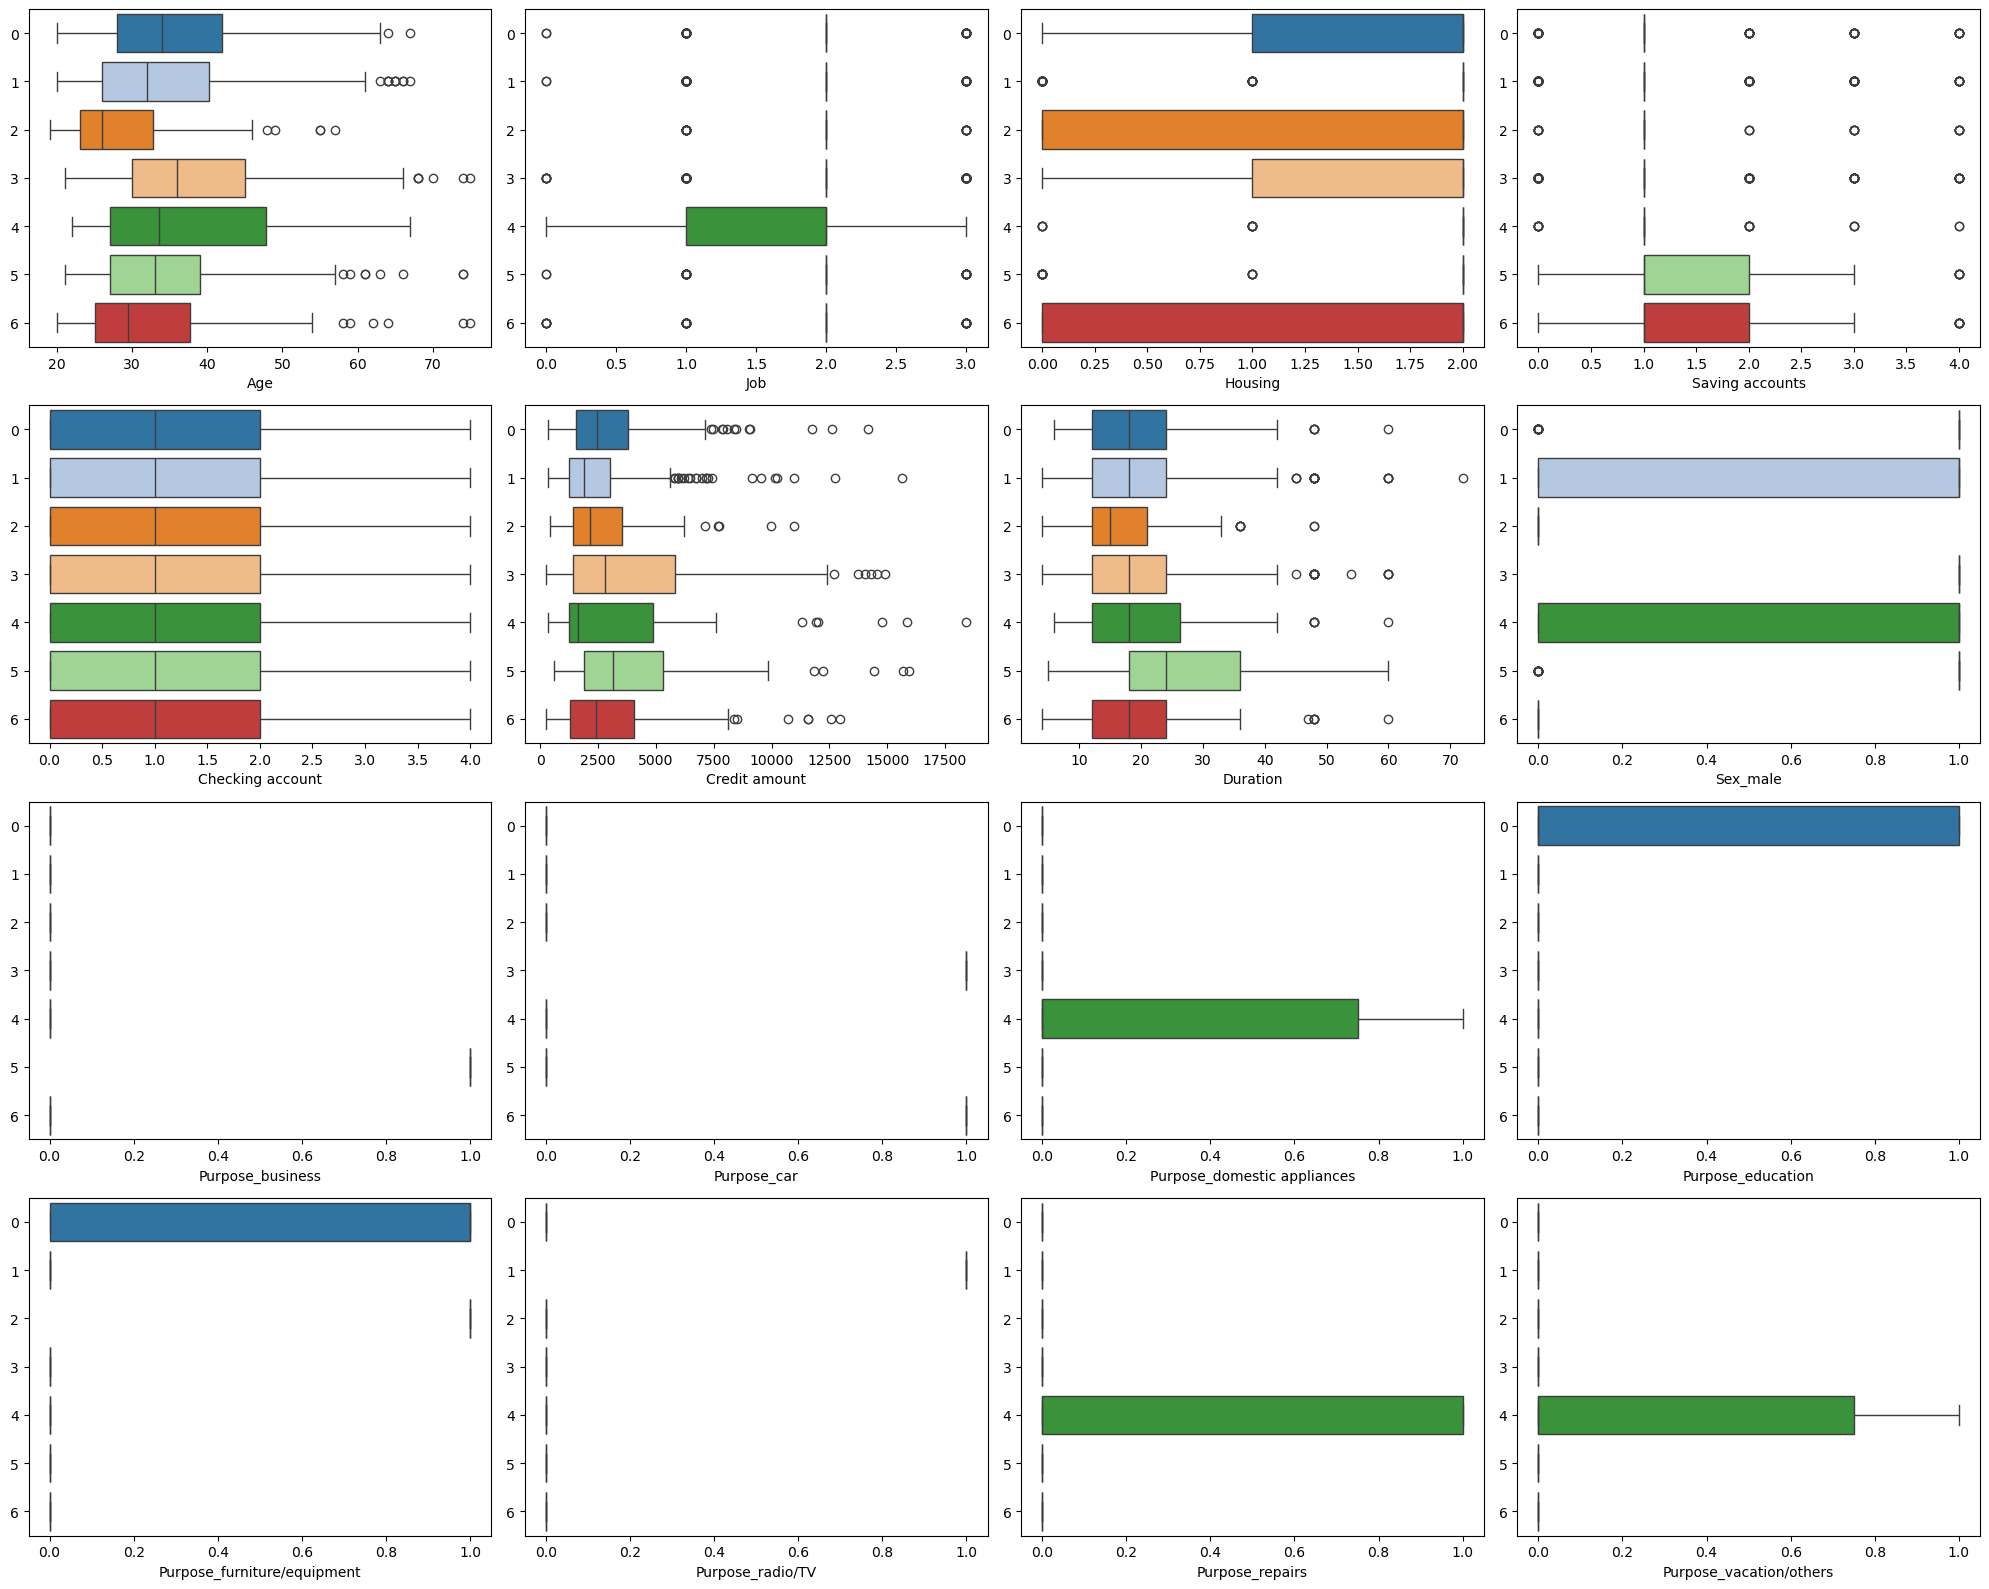

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))

for i, column in enumerate(encoded_df.drop(['labels'], axis=1).columns):
    sns.boxplot(data=encoded_df, x=encoded_df[column], y=labels, palette='tab20', orient='h', ax=axs[i//4][i%4])

fig.tight_layout()

##### **Интерпретации разделения**:
- Кластер 0 - берут кредиты только в целях обучения (1/3) или приобретения оборудования (2/3), преобладают мужчины (86%).
- Кластер 1 - берут кредиты только на ТВ и радио, преобладают мужчины (70%), запрашивают наименьшую среднюю сумму по кредиту.
- Кластер 2 - берут кредиты только на оборудование, состоит только из женщин, имеют наименьший средний возраст среди всех кластеров, запрашивают кредиты на наименьший средний срок.
- Кластер 3 - берут кредиты только на автомобили, состоит только из мужчин, имеют наибольший средний возраст, более чем в половине случаем имеют малый остаток на сберегательном счете.
- Кластер 4 - берут кредиты на ремонт (1/2), на бытовую технику (1/4) или прочие нужды (1/4), преобладают мужчины (70%), запрашивают наименьшуюю медианную сумму кредита.
- Кластер 5 - берут кредиты только на бизнес, преобладают мужчины (80%), кредит запрашивают на наибольшую среднюю сумму и наибольший срок по всем показателям.
- Кластер 6 - берут кредиты только на автомобили, состоит только из женщин, имеют наименьший средний остаток на текущем счете.

Общий вывод - разделение в основном произошло по целям кредита и половому признаку.

In [326]:
for i in np.unique(labels):
    print(f'Label {i}')
    print(encoded_df[encoded_df['labels']==i].drop(['labels'], axis=1).describe())
    print('\n')

Label 0
              Age         Job     Housing  Saving accounts  Checking account  \
count  166.000000  166.000000  166.000000       166.000000        166.000000   
mean    36.012048    1.897590    1.572289         1.156627          1.018072   
std     10.490970    0.609317    0.724600         0.946854          1.029698   
min     20.000000    0.000000    0.000000         0.000000          0.000000   
25%     28.000000    2.000000    1.000000         1.000000          0.000000   
50%     34.000000    2.000000    2.000000         1.000000          1.000000   
75%     42.000000    2.000000    2.000000         1.000000          2.000000   
max     67.000000    3.000000    2.000000         4.000000          4.000000   

       Credit amount    Duration    Sex_male  Purpose_business  Purpose_car  \
count     166.000000  166.000000  166.000000             166.0        166.0   
mean     3130.530120   20.054217    0.855422               0.0          0.0   
std      2359.586532   10.906910  